# Funciones, Derivadas y Gradientes

## Introducción

### ¿Qué es una función?

Una función es una relación que asigna a cada elemento de un conjunto de entrada un único elemento de un conjunto de salida. Formalmente, puede expresarse como:

$$
f: X \rightarrow Y
$$

donde cada elemento $x \in X$ se asocia con un valor $f(x) \in Y$.

- $X$ es el conjunto de entrada (también llamado dominio).
- $Y$ es el conjunto de salida (también llamado codominio).

Para cada elemento $x$ que pertenece al conjunto $X$, la función $f$ le asigna exactamente un valor en el conjunto $Y$. Ese valor se escribe como $f(x)$.

De manera intuitiva, una función puede entenderse como una regla que transforma una entrada en una salida. Por ejemplo:

$$
f(x) = x^2
$$

Esta función toma un valor numérico y devuelve su cuadrado. Aunque este ejemplo es simple, el mismo principio se aplica a funciones mucho más complejas.


### Funciones en Machine Learning

En Machine Learning, las funciones aparecen en dos niveles fundamentales:

Por un lado, un modelo puede interpretarse como una función que transforma datos de entrada en predicciones:

$$ 
\hat{y} = f(x; \theta)
$$

donde $x$ representa los datos de entrada, $\theta$ los parámetros del modelo y $\hat{y}$ la salida o predicción.

Por otro lado, para evaluar qué tan bien funciona el modelo, se define una función de pérdida:

$$
\mathcal{L}(\theta)
$$

Esta función mide el error entre las predicciones del modelo y los valores reales. El objetivo del entrenamiento es encontrar los parámetros que minimizan dicha función:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$


### El problema fundamental

Esto nos lleva al problema central: *dada una función, ¿cómo podemos encontrar los valores que la minimizan?*

En funciones simples, como $f(x) = x^2$, el mínimo es evidente. Sin embargo, en escenarios reales:

- Las funciones pueden depender de múltiples variables  
- No es posible visualizarlas directamente  
- Su comportamiento puede ser complejo  

Por lo tanto, no podemos depender únicamente de la intuición visual.

### Hacia derivadas y gradientes

Para poder encontrar mínimos de forma sistemática, necesitamos entender cómo cambia una función en un punto dado.

En particular, queremos responder preguntas como:

- ¿Qué ocurre si modificamos ligeramente la entrada?  
- ¿La función aumenta o disminuye?  
- ¿Qué tan rápido ocurre ese cambio?  

Responder estas preguntas requiere una herramienta que permita cuantificar el cambio local de una función. La derivada proporciona una medida precisa de cómo cambia una función en un punto. En una dimensión, este cambio se interpreta como la pendiente de la función. Cuando extendemos esta idea a funciones de múltiples variables, aparece el concepto de gradiente, que permite describir el cambio en espacios de mayor dimensión.

En esta notebook nos centraremos en construir estos conceptos desde cero, tanto desde una perspectiva intuitiva como computacional.

## Exploración de funciones simples

Antes de introducir herramientas formales como la derivada, es fundamental desarrollar una intuición clara sobre cómo se comportan las funciones. En esta sección trabajaremos con funciones simples de una variable, con el objetivo de entender visual y conceptualmente qué significa que una función “tenga un mínimo”. Esta intuición será la base sobre la cual construiremos todo lo demás.

### Funciones simples como punto de partida

Consideremos la siguiente función:

$$
f(x) = x^2
$$

Esta es una de las funciones más simples y, al mismo tiempo, más importantes en matemáticas. Su gráfica corresponde a una parábola abierta hacia arriba.

Si representamos esta función en un intervalo, por ejemplo $x \in [-5, 5]$, observamos lo siguiente:

- A medida que $x$ se aleja de $0$, el valor de la función crece  
- En $x = 0$, la función alcanza su valor más bajo posible  
- La función es simétrica respecto al eje vertical  

Este punto $x = 0$ se conoce como el **mínimo global** de la función.

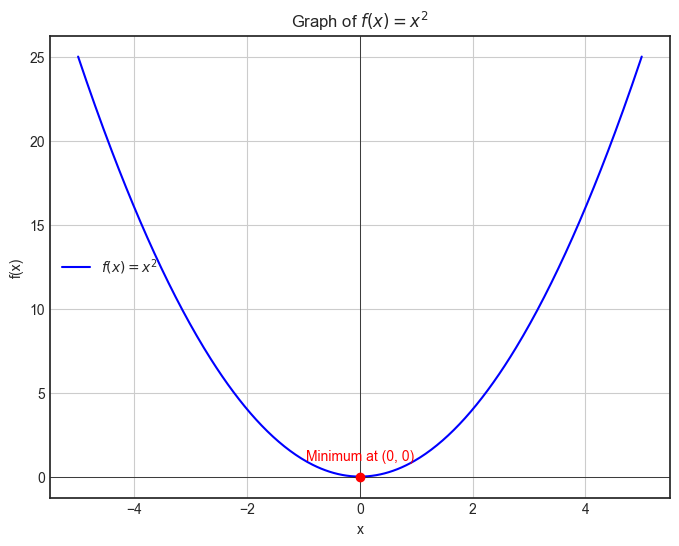

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function f(x) = x^2
def f(x):
    return x**2

# Generate x values from -5 to 5
x = np.linspace(-5, 5, 400)
y = f(x)  # Compute y values

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$f(x) = x^2$', color='blue')  # Plot parabola
plt.scatter(0, f(0), color='red', zorder=5)          # Mark minimum point
plt.text(0, f(0) + 1, 'Minimum at (0, 0)', ha='center', color='red')  # Add label

# Add titles and axis labels
plt.title('Graph of $f(x) = x^2$')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add grid and legend
plt.grid(True)
plt.legend(loc=6, frameon=False)

# Draw axis lines
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()


### Desplazamiento de funciones

Ahora consideremos una variante:

$$
f(x) = (x - 2)^2
$$

Esta función tiene exactamente la misma forma que $x^2$, pero está desplazada horizontalmente.

Al graficarla, observamos que:

- La forma parabólica se conserva  
- El punto más bajo ya no está en $x = 0$, sino en $x = 2$  
- El valor mínimo sigue siendo $0$, pero ocurre en una posición distinta  

Este ejemplo es importante porque muestra que la forma de una función determina su comportamiento, pero sus parámetros determinan dónde ocurren los puntos clave.  

En Machine Learning:    
- La función de costo define la forma general del problema de optimización (ej. cuadrática, logarítmica, etc.).  
- Los parámetros del modelo $(\theta)$ determinan la posición de los mínimos y, por lo tanto, el desempeño del modelo.  
- El entrenamiento consiste en ajustar esos parámetros para que el mínimo de la función de costo coincida con el mejor rendimiento posible.  

Así como en la parábola desplazada el mínimo se mueve de $(x=0)$ a $(x=2)$, en ML los parámetros desplazan y moldean la función de pérdida, indicando dónde se encuentran los puntos óptimos que guían el aprendizaje del modelo.

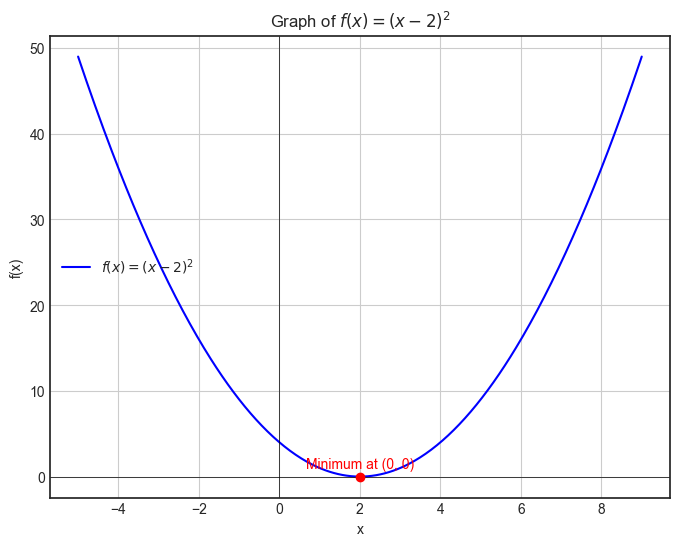

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function f(x) = x^2
def f(x):
    return (x-2)**2

# Generate x values from -5 to 9
x = np.linspace(-5, 9, 400)
y = f(x)  # Compute y values

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$f(x) = (x-2)^2$', color='blue')  # Plot parabola
plt.scatter(2, f(2), color='red', zorder=5)          # Mark minimum point
plt.text(2, f(2) + 1, 'Minimum at (0, 0)', ha='center', color='red')  # Add label

# Add titles and axis labels
plt.title('Graph of $f(x) = (x-2)^2$')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add grid and legend
plt.grid(True)
plt.legend(loc=6, frameon=False)

# Draw axis lines
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()

### Funciones sin mínimo claro

No todas las funciones tienen un mínimo global bien definido. Consideremos:

$$
f(x) = x^3
$$

Al graficar esta función, observamos que:

- La función decrece cuando $x < 0$  
- La función crece cuando $x > 0$  
- No existe un punto que pueda identificarse como el más bajo o el más alto  

Sin embargo, hay algo interesante en $x = 0$:

- La pendiente cambia de negativa a positiva  
- La función “se aplana” momentáneamente  

Este tipo de punto no es un mínimo ni un máximo, pero será relevante más adelante cuando estudiemos derivadas.

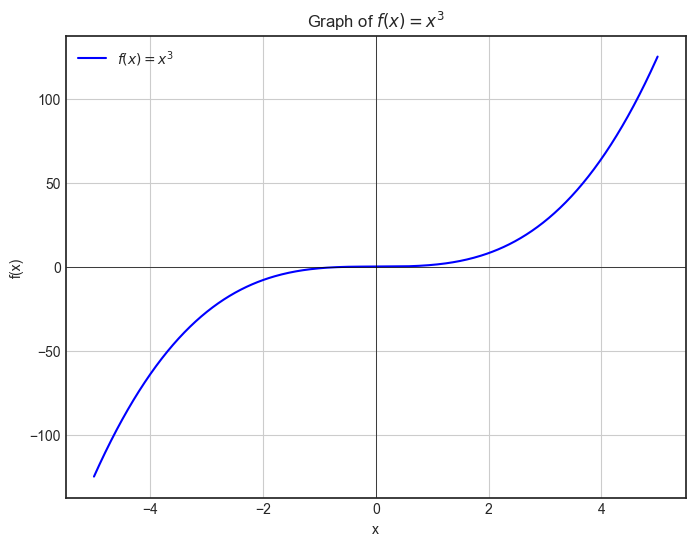

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function f(x) = x^3
def f(x):
    return x**3

# Generate x values from -5 to 5
x = np.linspace(-5, 5, 400)
y = f(x)  # Compute y values

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$f(x) = x^3$', color='blue')  # Plot parabola

# Add titles and axis labels
plt.title('Graph of $f(x) = x^3$')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add grid and legend
plt.grid(True)
plt.legend(loc=2, frameon=False)

# Draw axis lines
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()


### Indentificar el mínimo de una función

Desde una perspectiva visual, identificar un mínimo es sencillo:

- Es el punto donde la función alcanza su valor más bajo  
- Si nos movemos ligeramente hacia la izquierda o derecha, el valor de la función aumenta  

Formalmente, un punto $x^*$ es un mínimo global de la función $f$ si el valor de la función en $x^*$ es menor o igual que el valor de la función en cualquier otro punto $x$ del dominio.

$$
f(x^*) \leq f(x) \quad \forall x
$$

En términos más intuitivos:

*Un mínimo es un punto desde el cual cualquier pequeño movimiento incrementa el valor de la función.*

Podemos interpretar esto de forma geométrica:

- Imaginemos la gráfica como una superficie.
- Un mínimo corresponde al punto más bajo accesible.
- Si colocamos una esfera en ese punto, no tendría hacia dónde rodar hacia abajo.

Esta interpretación será especialmente útil cuando pasemos a funciones en múltiples dimensiones.

En Machine Learning, cuando entrenamos un modelo, buscamos los parámetros $(\theta^*)$ que minimizan la función de pérdida $\mathcal{L}(\theta)$.  Es decir, el error en $(\theta^*)$ es menor o igual que en cualquier otro conjunto de parámetros.

### El problema que queda abierto

Hasta este punto, podemos identificar un mínimo si vemos la función. Pero, *¿cómo encontramos ese mínimo sin poder visualizar la función?*

En problemas reales, las funciones de pérdida pueden depender de cientos o miles de variables:

$$
\mathcal{L}(\theta_1, \theta_2, \dots, \theta_n)
$$

En estos casos, la visualización directa deja de ser una opción.

Para resolver este problema, necesitamos una forma de analizar el comportamiento de la función en un punto específico, sin depender de su gráfica completa.

En particular, necesitamos responder:

- ¿La función está aumentando o disminuyendo en este punto?  
- ¿Qué tan rápido cambia?  
- ¿Qué ocurre si nos movemos ligeramente?  

Estas preguntas nos llevan directamente al concepto de derivada, como herramienta que permite medir el cambio local de una función. A diferencia de la inspección visual, la derivada proporciona una forma precisa, general y computable de analizar funciones, incluso cuando no pueden ser visualizadas.